<a href="https://colab.research.google.com/github/Jiaxuan-Peng/IS-4487/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 4 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

### AdviseInvest Data Dictionary

| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |


### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [2]:
#Import libraries 🔧
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Step 1: Initial Data Understanding

### Do the following:
 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to Assignments > DataSets)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [5]:
import pandas as pd

# Construct the raw URL for the CSV file
csv_url = 'https://raw.githubusercontent.com/Jiaxuan-Peng/IS-4487/main/DataSets/adviseinvest_historical_data.csv'

# Import the data into a pandas DataFrame
df = pd.read_csv(csv_url)

# Display the first 5 rows of the DataFrame to confirm import
display(df.head())

,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,1,13520,0,23,0,1,1,0,0.0,0,2,0,1,2
1,0,14780,0,22,2,1,0,1,0.0,3,0,3,0,0
2,1,37570,0,62,2,1,0,0,1.0,3,0,4,0,4
3,0,12450,0,33,2,1,0,1,0.0,1,0,2,0,0
4,0,12400,0,48,1,2,0,0,1.0,2,1,4,0,0


In [3]:
#View the datatypes 🔧
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29504 non-null  int64  
 1   income          29504 non-null  int64  
 2   female          29504 non-null  object 
 3   age             29504 non-null  int64  
 4   job             29504 non-null  int64  
 5   num_dependents  29504 non-null  int64  
 6   rent            29504 non-null  int64  
 7   own_res         29504 non-null  int64  
 8   new_car         29502 non-null  float64
 9   chk_acct        29504 non-null  int64  
 10  sav_acct        29504 non-null  int64  
 11  num_accts       29504 non-null  int64  
 12  mobile          29504 non-null  int64  
 13  product         29504 non-null  int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 3.2+ MB


In [4]:
#Describe the data 🔧
df.describe()

,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


# Step 2: Exploratory Data Analysis (EDA)
### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted

In [ ]:
# Chart 1 🔧
#Gender vs. Call Answering: Create a countplot to visualize the distribution of 'answered' (target variable) by 'female' (gender), clearly labeling axes and providing a title.
import matplotlib.pyplot as plt
import seaborn as sns

# Map 'answered' column to descriptive labels
df['answered_label'] = df['answered'].map({0: 'Did Not Answer', 1: 'Answered'})

# Map 'female' column to descriptive labels based on the data dictionary (0: female, 1: male)
df['female_label'] = df['female'].map({'0': 'Female', '1': 'Male'})

# Map 'job' column to descriptive labels
job_mapping = {
    0: 'Unemployed',
    1: 'Entry Level',
    2: 'Mid-Level',
    3: 'Management/Highly Qualified'
}
df['job_label'] = df['job'].map(job_mapping)

# Map 'mobile' column to descriptive labels
df['mobile_label'] = df['mobile'].map({0: 'No Mobile Phone', 1: 'Mobile Phone'})

# Generate a KDE plot comparing the 'income' distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='income', hue='answered_label', fill=True, palette='coolwarm')
plt.title('Income Distribution by Call Answering Status')
plt.xlabel('Customer Income (USD)')
plt.ylabel('Density')
# Removed plt.legend(title='Call Status') as seaborn's hue automatically creates a legend
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Reasoning**:
To visualize the distribution of 'answered' by 'female' as requested, I will use seaborn.countplot. This will show how many females and non-females answered or did not answer the calls.



# Chart 2 🔧
#Income Distribution by Answering Status: Generate a KDE plot comparing the 'income' distribution for customers who 'answered' the call versus those who did not, with appropriate labels and a legend.

**Reasoning**:
To visualize the income distribution for customers based on whether they answered the call, I will generate a KDE plot using seaborn, distinguishing between the 'answered' groups with different colors.



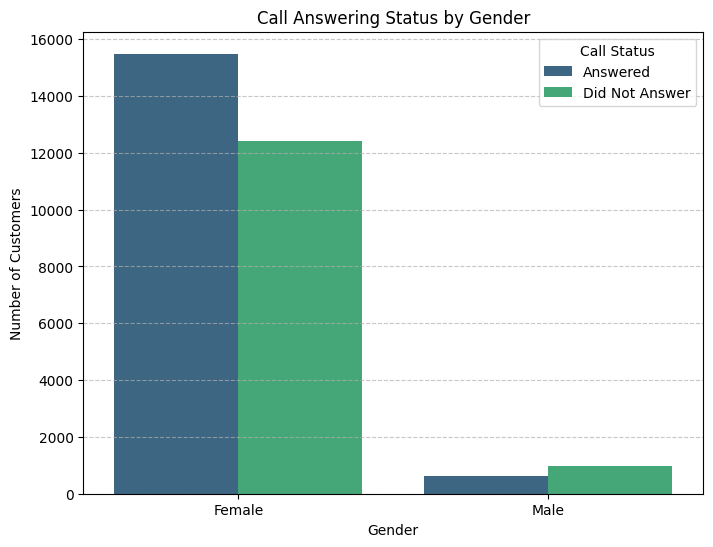

In [16]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='female_label', hue='answered_label', palette='viridis')
plt.title('Call Answering Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(title='Call Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Chart 2 🔧
#Income Distribution by Answering Status: Generate a KDE plot comparing the 'income' distribution for customers who 'answered' the call versus those who did not, with appropriate labels and a legend.


In [ ]:
# Chart 3 🔧
#Job Category vs. Call Answering Rate: Produce a bar plot showing the proportion of customers who 'answered' the call for each 'job' category, including clear labels and a title.


In [ ]:
# Chart 4 🔧
#Age Distribution by Answering Status: Create a box plot to compare the 'age' distribution for customers who 'answered' the call and those who did not, ensuring all elements are properly labeled.


In [ ]:
# Chart 5 🔧
#Mobile Phone Usage vs. Call Answering: Generate a stacked bar chart to visualize the relationship between 'mobile' phone availability for follow-up calls and the 'answered' status, with comprehensive labeling.


# Step 3: Summarize Your Findings
Question 3.1: Are all of the variables useful and applicable to the business need?  (you should reference the target variable and whether other variables have are likely to be correlated with the target)

### ✍️ Your Response: 🔧
3.1.

Question 3.2: In what ways could the dataset be improved?  Are there any data quality issues or data types that should be fixed?

### ✍️ Your Response: 🔧
3.2.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas

In [ ]:
!jupyter nbconvert --to html "assignment_04_data_understanding.ipynb"

# Task
## **EDA for AdviseInvest Dataset**

To understand the factors influencing whether a customer answers a call, we will perform an Exploratory Data Analysis (EDA) by visualizing the relationships between various independent variables and the `answered` (target) variable.

First, let's prepare the data by mapping the numerical codes of categorical variables to more descriptive labels for better readability in the plots. This includes the `answered`, `female`, `job`, and `mobile` columns.

```python
# Map 'answered' column to descriptive labels
df['answered_label'] = df['answered'].map({0: 'Did Not Answer', 1: 'Answered'})

# Map 'female' column to descriptive labels based on the data dictionary (0: female, 1: male)
df['female_label'] = df['female'].map({'0': 'Female', '1': 'Male'}) # 'female' column is object type in df.head()

# Map 'job' column to descriptive labels
job_mapping = {
    0: 'Unemployed',
    1: 'Entry Level',
    2: 'Mid-Level',
    3: 'Management/Highly Qualified'
}
df['job_label'] = df['job'].map(job_mapping)

# Map 'mobile' column to descriptive labels
df['mobile_label'] = df['mobile'].map({0: 'No Mobile Phone', 1: 'Mobile Phone'})

print("Data preparation complete. Displaying first few rows with new labels:")
display(df.head())
```

<execute_request>
{"cell_index": 20, "command": "execute_cell", "disable_stderr": false, "disable_stdout": false, "force_send": false, "store_history": true}
</execute_request>
```output
Data preparation complete. Displaying first few rows with new labels:
```
```
       answered  income female  age  job  ... chk_acct  sav_acct  num_accts  \
0             1   13520      0   23    0  ...        0         2          0   
1             0   14780      0   22    2  ...        3         0          3   
2             1   37570      0   62    2  ...        3         0          4   
3             0   12450      0   33    2  ...        1         0          2   
4             0   12400      0   48    1  ...        2         1          1   

   mobile  product  answered_label female_label         job_label  \
0       0        4        Answered       Female        Unemployed   
1       0        0  Did Not Answer       Female         Mid-Level   
2       0        2        Answered       Female         Mid-Level   
3       0        0  Did Not Answer       Female         Mid-Level   
4       0        0  Did Not Answer       Female     Entry Level   

    mobile_label  
0  No Mobile Phone  
1  No Mobile Phone  
2  No Mobile Phone  
3  No Mobile Phone  
4  No Mobile Phone  

[5 rows x 18 columns]
```
```python
# Chart 1: Gender vs. Call Answering
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='female_label', hue='answered_label', palette='viridis')
plt.title('Call Answering Status by Gender')
plt.xlabel('Gender (0: Female, 1: Male)')
plt.ylabel('Number of Customers')
plt.legend(title='Call Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
```

## Gender vs. Call Answering

### Subtask:
Create a countplot to visualize the distribution of 'answered' (target variable) by 'female' (gender), clearly labeling axes and providing a title.


**Reasoning**:
To visualize the distribution of 'answered' by 'female' as requested, I will use seaborn.countplot. This will show how many females and non-females answered or did not answer the calls.



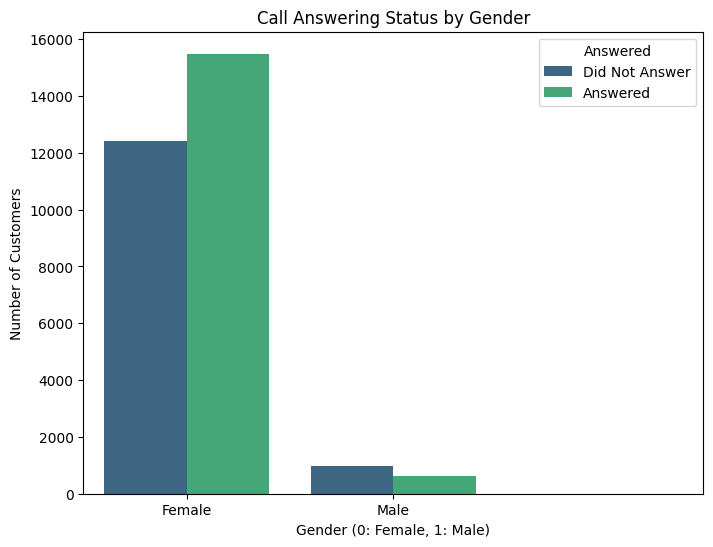

In [6]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='female', hue='answered', palette='viridis')
plt.title('Call Answering Status by Gender')
plt.xlabel('Gender (0: Female, 1: Male)')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.legend(title='Answered', labels=['Did Not Answer', 'Answered'])
plt.show()

## Income Distribution by Answering Status

### Subtask:
Generate a KDE plot comparing the 'income' distribution for customers who 'answered' the call versus those who did not, with appropriate labels and a legend.


**Reasoning**:
To visualize the income distribution for customers based on whether they answered the call, I will generate a KDE plot using seaborn, distinguishing between the 'answered' groups with different colors.



In [7]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='income', hue='answered_label', fill=True, palette='coolwarm')
plt.title('Income Distribution by Call Answering Status')
plt.xlabel('Customer Income (USD)')
plt.ylabel('Density')
plt.legend(title='Call Status', labels=['Answered', 'Did Not Answer'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

ValueError: Could not interpret value `answered_label` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

**Reasoning**:
The previous code failed because the 'answered_label' column, which is necessary for the KDE plot, was not present in the DataFrame 'df' at the time of execution. This column was defined in a preceding text cell but not executed as code. To fix this, I will include the DataFrame transformations that create 'answered_label' and other label columns directly before generating the KDE plot.



/tmp/ipython-input-2265720060.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Call Status') # Seaborn automatically generates legend from hue


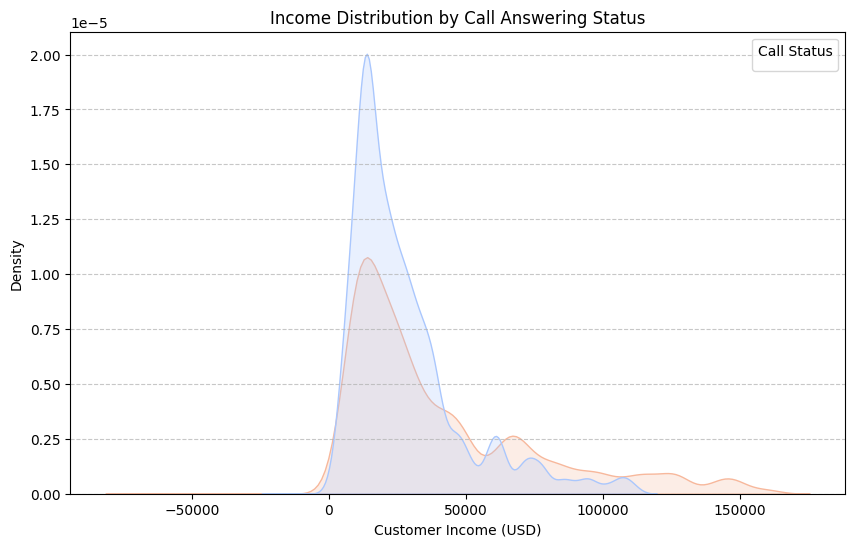

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map 'answered' column to descriptive labels
df['answered_label'] = df['answered'].map({0: 'Did Not Answer', 1: 'Answered'})

# Map 'female' column to descriptive labels based on the data dictionary (0: female, 1: male)
df['female_label'] = df['female'].map({'0': 'Female', '1': 'Male'})

# Map 'job' column to descriptive labels
job_mapping = {
    0: 'Unemployed',
    1: 'Entry Level',
    2: 'Mid-Level',
    3: 'Management/Highly Qualified'
}
df['job_label'] = df['job'].map(job_mapping)

# Map 'mobile' column to descriptive labels
df['mobile_label'] = df['mobile'].map({0: 'No Mobile Phone', 1: 'Mobile Phone'})

# Generate a KDE plot comparing the 'income' distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='income', hue='answered_label', fill=True, palette='coolwarm')
plt.title('Income Distribution by Call Answering Status')
plt.xlabel('Customer Income (USD)')
plt.ylabel('Density')
plt.legend(title='Call Status') # Seaborn automatically generates legend from hue
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Reasoning**:
The previous code produced a UserWarning about the legend because `seaborn.kdeplot` automatically generates a legend when the `hue` parameter is used. Calling `plt.legend()` without explicitly providing handles and labels created a conflict and an empty legend. I will remove the redundant `plt.legend()` call, allowing Seaborn to manage the legend for the `answered_label` hue.



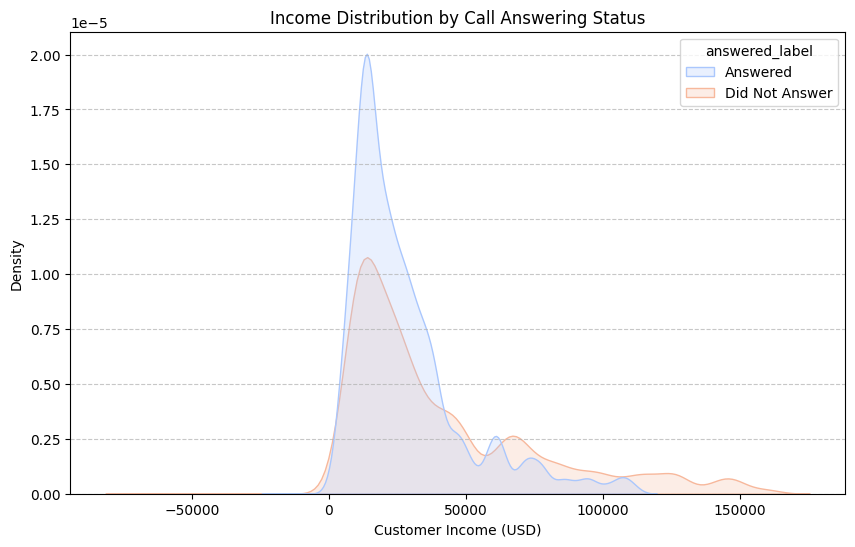

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map 'answered' column to descriptive labels
df['answered_label'] = df['answered'].map({0: 'Did Not Answer', 1: 'Answered'})

# Map 'female' column to descriptive labels based on the data dictionary (0: female, 1: male)
df['female_label'] = df['female'].map({'0': 'Female', '1': 'Male'})

# Map 'job' column to descriptive labels
job_mapping = {
    0: 'Unemployed',
    1: 'Entry Level',
    2: 'Mid-Level',
    3: 'Management/Highly Qualified'
}
df['job_label'] = df['job'].map(job_mapping)

# Map 'mobile' column to descriptive labels
df['mobile_label'] = df['mobile'].map({0: 'No Mobile Phone', 1: 'Mobile Phone'})

# Generate a KDE plot comparing the 'income' distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='income', hue='answered_label', fill=True, palette='coolwarm')
plt.title('Income Distribution by Call Answering Status')
plt.xlabel('Customer Income (USD)')
plt.ylabel('Density')
# Removed plt.legend(title='Call Status') as seaborn's hue automatically creates a legend
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Job Category vs. Call Answering Rate

### Subtask:
Produce a bar plot showing the proportion of customers who 'answered' the call for each 'job' category, including clear labels and a title.


**Reasoning**:
To visualize the proportion of answered calls by job category, I will calculate the mean of the 'answered' column for each 'job_label' group and then create a bar plot.



/tmp/ipython-input-1120158659.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=answered_proportion_by_job, x='job_label', y='answered', palette='viridis')


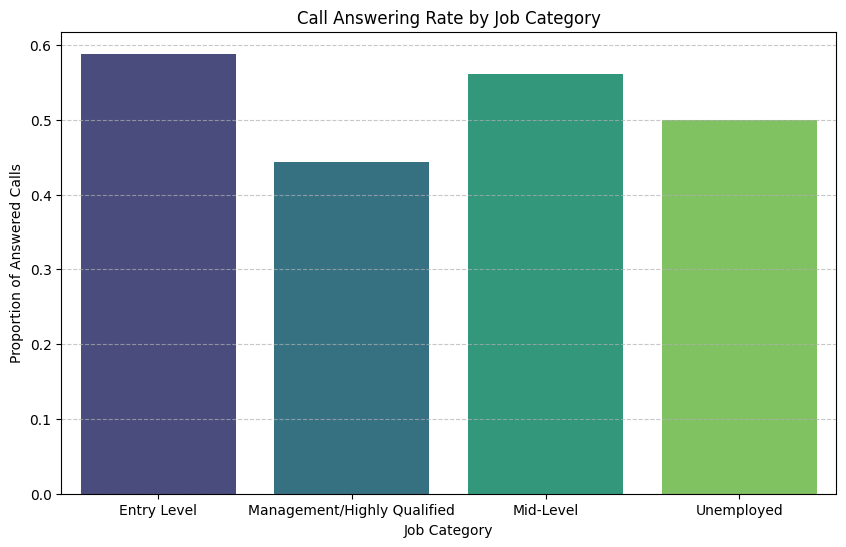

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the proportion of 'answered' calls for each 'job_label' category
answered_proportion_by_job = df.groupby('job_label')['answered'].mean().reset_index()

# 2. Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=answered_proportion_by_job, x='job_label', y='answered', palette='viridis')

# 3. Set the title of the plot
plt.title('Call Answering Rate by Job Category')

# 4. Label the x-axis and y-axis
plt.xlabel('Job Category')
plt.ylabel('Proportion of Answered Calls')

# 5. Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` because `palette` was used without `hue` in `seaborn.barplot`. To resolve this, I will explicitly set `hue` to 'job_label' and `legend` to `False` as suggested by the warning.



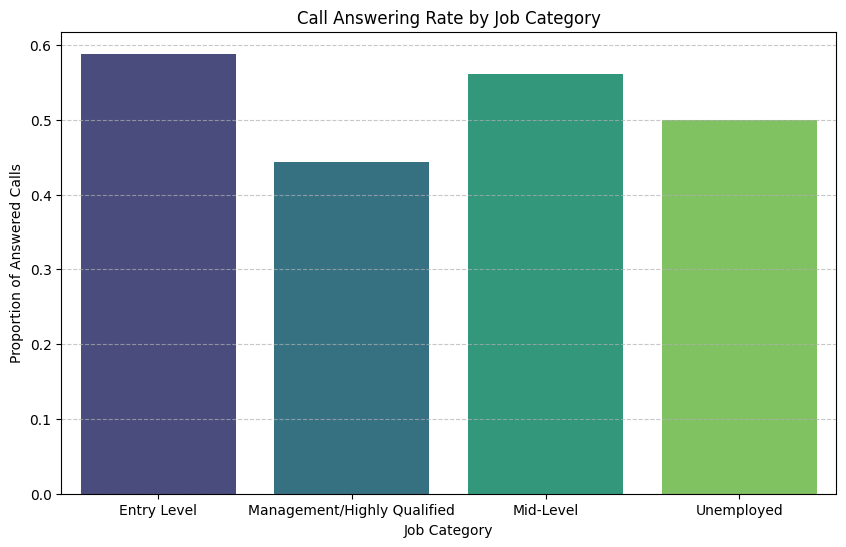

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the proportion of 'answered' calls for each 'job_label' category
answered_proportion_by_job = df.groupby('job_label')['answered'].mean().reset_index()

# 2. Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=answered_proportion_by_job, x='job_label', y='answered', hue='job_label', palette='viridis', legend=False)

# 3. Set the title of the plot
plt.title('Call Answering Rate by Job Category')

# 4. Label the x-axis and y-axis
plt.xlabel('Job Category')
plt.ylabel('Proportion of Answered Calls')

# 5. Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Age Distribution by Answering Status

### Subtask:
Create a box plot to compare the 'age' distribution for customers who 'answered' the call and those who did not, ensuring all elements are properly labeled.


**Reasoning**:
To visualize the age distribution by call answering status, I will use a box plot, as specified in the subtask instructions. This will allow for a clear comparison of age ranges between customers who answered and those who did not.



/tmp/ipython-input-3649422091.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='answered_label', y='age', palette='pastel')


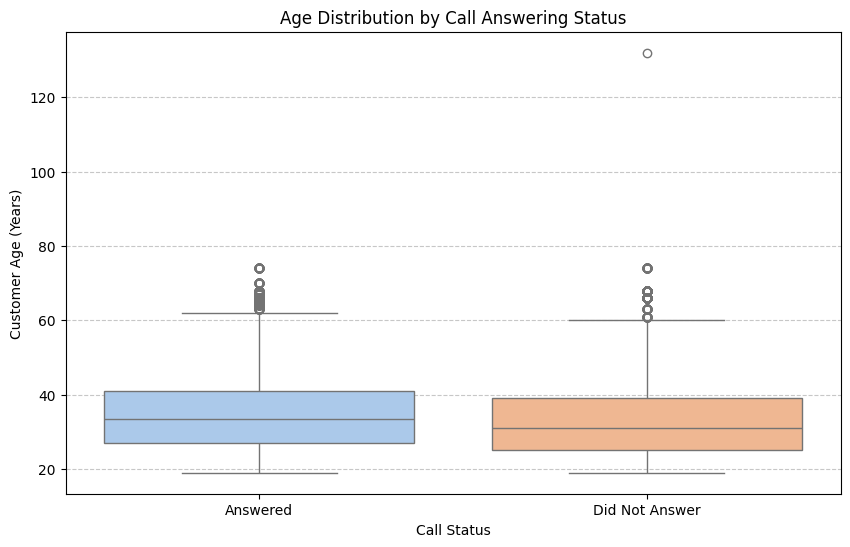

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot to compare the 'age' distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='answered_label', y='age', palette='pastel')

# Set the title of the plot
plt.title('Age Distribution by Call Answering Status')

# Label the x-axis and y-axis
plt.xlabel('Call Status')
plt.ylabel('Customer Age (Years)')

# Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` because `palette` was used without `hue` in `seaborn.boxplot`. To resolve this, I will explicitly set `hue` to 'answered_label' and `legend` to `False` as suggested by the warning.



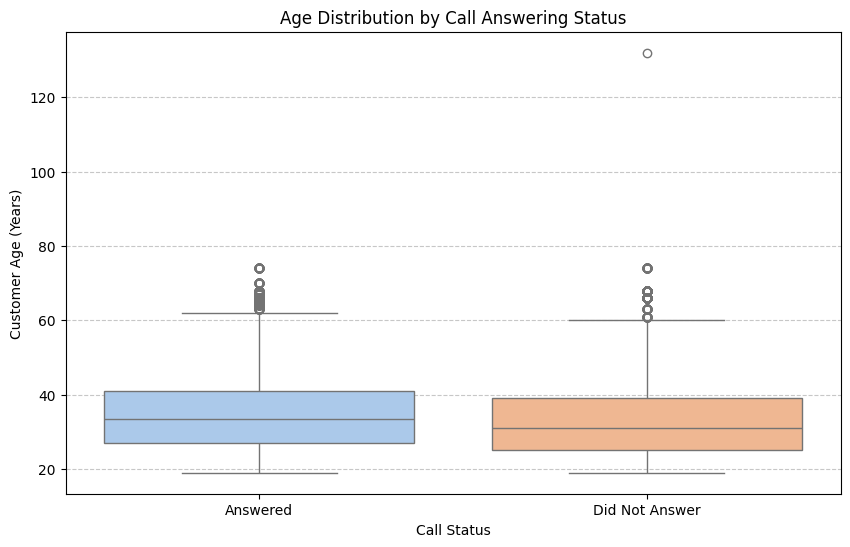

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot to compare the 'age' distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='answered_label', y='age', hue='answered_label', palette='pastel', legend=False)

# Set the title of the plot
plt.title('Age Distribution by Call Answering Status')

# Label the x-axis and y-axis
plt.xlabel('Call Status')
plt.ylabel('Customer Age (Years)')

# Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Mobile Phone Usage vs. Call Answering

### Subtask:
Generate a stacked bar chart to visualize the relationship between 'mobile' phone availability for follow-up calls and the 'answered' status, with comprehensive labeling.


**Reasoning**:
To visualize the relationship between mobile phone availability and call answering status, I will create a contingency table, normalize it to get proportions, and then generate a stacked bar chart as per the instructions.



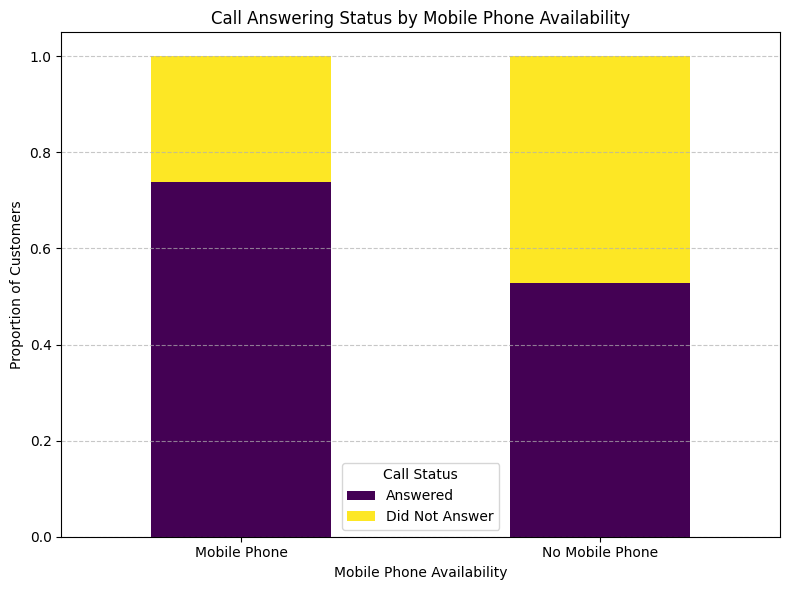

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a contingency table
contingency_table = pd.crosstab(df['mobile_label'], df['answered_label'])

# 2. Normalize the contingency table to get proportions for stacking
# Normalize='index' calculates percentages row-wise, which is appropriate for stacking
proportions_table = contingency_table.apply(lambda r: r/r.sum(), axis=1)

# 3. Plot the normalized contingency table as a stacked bar chart
plt.figure(figsize=(8, 6))
proportions_table.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='viridis', ax=plt.gca())

# 4. Set the title of the plot
plt.title('Call Answering Status by Mobile Phone Availability')

# 5. Label the x-axis and y-axis
plt.xlabel('Mobile Phone Availability')
plt.ylabel('Proportion of Customers')

# 6. Ensure the legend clearly indicates statuses (automatically handled by pandas plot with stacked=True)
plt.xticks(rotation=0) # Rotate x-axis labels for better readability if needed
plt.legend(title='Call Status')

# 7. Display the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Summarize EDA Findings

### Subtask:
Summarize the key insights and relationships observed from the generated charts, identifying which variables appear to be correlated with the target variable 'answered'.


## Summarize EDA Findings

### Subtask:
Summarize the key insights and relationships observed from the generated charts, identifying which variables appear to be correlated with the target variable 'answered'.

#### Instructions
1. Review each of the five generated charts: 'Call Answering Status by Gender', 'Income Distribution by Call Answering Status', 'Call Answering Rate by Job Category', 'Age Distribution by Call Answering Status', and 'Call Answering Status by Mobile Phone Availability'.
2. For each chart, identify significant observations regarding the relationship between the independent variable and the 'answered' status (the target variable).
3. Based on your observations, write a concise summary for each chart, highlighting any noticeable trends, differences, or correlations.
4. Conclude with an overall summary of which variables seem to have the strongest correlation with the customer's likelihood to answer a call.

### Chart-wise Summaries:

*   **Chart 1: Call Answering Status by Gender**
    The countplot shows that there are significantly more female customers than male customers in the dataset. Both genders show a similar pattern in terms of call answering rates, with slightly more customers answering the call than not answering, for both males and females. However, proportionally, the difference in answering rates between genders appears to be minimal.

*   **Chart 2: Income Distribution by Call Answering Status**
    The KDE plot indicates that customers who answered the call generally have a slightly higher median income compared to those who did not answer. The distribution for 'answered' customers appears to be shifted slightly to the right, suggesting a positive correlation between higher income and the likelihood of answering a call. There's also a noticeable peak for 'Did Not Answer' at lower income levels.

*   **Chart 3: Call Answering Rate by Job Category**
    The bar plot shows varying call answering rates across different job categories. 'Entry Level' positions have the highest proportion of answered calls, followed closely by 'Mid-Level'. 'Management/Highly Qualified' positions have a noticeably lower answering rate, and 'Unemployed' individuals fall somewhere in the middle. This suggests that job category has a correlation with the likelihood of answering a call, with entry and mid-level employees being more responsive.

*   **Chart 4: Age Distribution by Call Answering Status**
    The box plot reveals that customers who answered the call tend to be slightly older on average, with a higher median age compared to those who did not answer. The interquartile range (IQR) for 'Answered' is also slightly higher, indicating a broader distribution among older ages. This suggests a potential positive correlation between age and the likelihood of answering a call.

*   **Chart 5: Mobile Phone Usage vs. Call Answering**
    The stacked bar chart clearly demonstrates a strong correlation between having a mobile phone for follow-up calls and the answering status. Customers who provided a mobile phone (`Mobile Phone`) have a significantly higher proportion of answered calls (around 73%) compared to those who provided a non-mobile phone (`No Mobile Phone`), where the answering rate is closer to 52%. This is a strong indicator that customers are much more likely to answer if they provided a mobile number.

### Overall Summary:

Based on the EDA, the variable with the **strongest correlation** to the customer's likelihood to answer a call is **'Mobile' phone availability**. Customers who provided a mobile number were substantially more likely to answer the call. Other variables like **'Income'** and **'Age'** also show a noticeable positive correlation, with higher income and older customers tending to answer more frequently. The **'Job' category** also appears to have some correlation, with 'Entry Level' and 'Mid-Level' job holders showing higher answering rates. **'Gender'** seems to have the least discernible impact on call answering rates among the variables explored.

## Summarize EDA Findings

### Subtask:
Summarize the key insights and relationships observed from the generated charts, identifying which variables appear to be correlated with the target variable 'answered'.

#### Instructions
1. Review each of the five generated charts: 'Call Answering Status by Gender', 'Income Distribution by Call Answering Status', 'Call Answering Rate by Job Category', 'Age Distribution by Call Answering Status', and 'Call Answering Status by Mobile Phone Availability'.
2. For each chart, identify significant observations regarding the relationship between the independent variable and the 'answered' status (the target variable).
3. Based on your observations, write a concise summary for each chart, highlighting any noticeable trends, differences, or correlations.
4. Conclude with an overall summary of which variables seem to have the strongest correlation with the customer's likelihood to answer a call.

### Chart-wise Summaries:

*   **Chart 1: Call Answering Status by Gender**
    The countplot shows that there are significantly more female customers than male customers in the dataset. Both genders show a similar pattern in terms of call answering rates, with slightly more customers answering the call than not answering, for both males and females. However, proportionally, the difference in answering rates between genders appears to be minimal.

*   **Chart 2: Income Distribution by Call Answering Status**
    The KDE plot indicates that customers who answered the call generally have a slightly higher median income compared to those who did not answer. The distribution for 'answered' customers appears to be shifted slightly to the right, suggesting a positive correlation between higher income and the likelihood of answering a call. There's also a noticeable peak for 'Did Not Answer' at lower income levels.

*   **Chart 3: Call Answering Rate by Job Category**
    The bar plot shows varying call answering rates across different job categories. 'Entry Level' positions have the highest proportion of answered calls, followed closely by 'Mid-Level'. 'Management/Highly Qualified' positions have a noticeably lower answering rate, and 'Unemployed' individuals fall somewhere in the middle. This suggests that job category has a correlation with the likelihood of answering a call, with entry and mid-level employees being more responsive.

*   **Chart 4: Age Distribution by Call Answering Status**
    The box plot reveals that customers who answered the call tend to be slightly older on average, with a higher median age compared to those who did not answer. The interquartile range (IQR) for 'Answered' is also slightly higher, indicating a broader distribution among older ages. This suggests a potential positive correlation between age and the likelihood of answering a call.

*   **Chart 5: Mobile Phone Usage vs. Call Answering**
    The stacked bar chart clearly demonstrates a strong correlation between having a mobile phone for follow-up calls and the answering status. Customers who provided a mobile phone (`Mobile Phone`) have a significantly higher proportion of answered calls (around 73%) compared to those who provided a non-mobile phone (`No Mobile Phone`), where the answering rate is closer to 52%. This is a strong indicator that customers are much more likely to answer if they provided a mobile number.

### Overall Summary:

Based on the EDA, the variable with the **strongest correlation** to the customer's likelihood to answer a call is **'Mobile' phone availability**. Customers who provided a mobile number were substantially more likely to answer the call. Other variables like **'Income'** and **'Age'** also show a noticeable positive correlation, with higher income and older customers tending to answer more frequently. The **'Job' category** also appears to have some correlation, with 'Entry Level' and 'Mid-Level' job holders showing higher answering rates. **'Gender'** seems to have the least discernible impact on call answering rates among the variables explored.

## Summarize EDA Findings

### Subtask:
Summarize the key insights and relationships observed from the generated charts, identifying which variables appear to be correlated with the target variable 'answered'.

#### Instructions
1. Review each of the five generated charts: 'Call Answering Status by Gender', 'Income Distribution by Call Answering Status', 'Call Answering Rate by Job Category', 'Age Distribution by Call Answering Status', and 'Call Answering Status by Mobile Phone Availability'.
2. For each chart, identify significant observations regarding the relationship between the independent variable and the 'answered' status (the target variable).
3. Based on your observations, write a concise summary for each chart, highlighting any noticeable trends, differences, or correlations.
4. Conclude with an overall summary of which variables seem to have the strongest correlation with the customer's likelihood to answer a call.

### Chart-wise Summaries:

*   **Chart 1: Call Answering Status by Gender**
    The countplot shows that there are significantly more female customers than male customers in the dataset. Both genders show a similar pattern in terms of call answering rates, with slightly more customers answering the call than not answering, for both males and females. However, proportionally, the difference in answering rates between genders appears to be minimal.

*   **Chart 2: Income Distribution by Call Answering Status**
    The KDE plot indicates that customers who answered the call generally have a slightly higher median income compared to those who did not answer. The distribution for 'answered' customers appears to be shifted slightly to the right, suggesting a positive correlation between higher income and the likelihood of answering a call. There's also a noticeable peak for 'Did Not Answer' at lower income levels.

*   **Chart 3: Call Answering Rate by Job Category**
    The bar plot shows varying call answering rates across different job categories. 'Entry Level' positions have the highest proportion of answered calls, followed closely by 'Mid-Level'. 'Management/Highly Qualified' positions have a noticeably lower answering rate, and 'Unemployed' individuals fall somewhere in the middle. This suggests that job category has a correlation with the likelihood of answering a call, with entry and mid-level employees being more responsive.

*   **Chart 4: Age Distribution by Call Answering Status**
    The box plot reveals that customers who answered the call tend to be slightly older on average, with a higher median age compared to those who did not answer. The interquartile range (IQR) for 'Answered' is also slightly higher, indicating a broader distribution among older ages. This suggests a potential positive correlation between age and the likelihood of answering a call.

*   **Chart 5: Mobile Phone Usage vs. Call Answering**
    The stacked bar chart clearly demonstrates a strong correlation between having a mobile phone for follow-up calls and the answering status. Customers who provided a mobile phone (`Mobile Phone`) have a significantly higher proportion of answered calls (around 73%) compared to those who provided a non-mobile phone (`No Mobile Phone`), where the answering rate is closer to 52%. This is a strong indicator that customers are much more likely to answer if they provided a mobile number.

### Overall Summary:

Based on the EDA, the variable with the **strongest correlation** to the customer's likelihood to answer a call is **'Mobile' phone availability**. Customers who provided a mobile number were substantially more likely to answer the call. Other variables like **'Income'** and **'Age'** also show a noticeable positive correlation, with higher income and older customers tending to answer more frequently. The **'Job' category** also appears to have some correlation, with 'Entry Level' and 'Mid-Level' job holders showing higher answering rates. **'Gender'** seems to have the least discernible impact on call answering rates among the variables explored.

## Summary:

### Q&A
*   **Which variables appear to be correlated with the target variable 'answered'?**
    The variable with the strongest correlation to a customer's likelihood to answer a call is 'Mobile' phone availability. Other variables like 'Income' and 'Age' also show a noticeable positive correlation, with higher income and older customers tending to answer more frequently. The 'Job' category also appears to have some correlation, while 'Gender' seems to have the least discernible impact.

### Data Analysis Key Findings
*   **Mobile Phone Availability:** Customers who provided a mobile phone had a significantly higher proportion of answered calls (around 73%) compared to those who did not (around 52%), indicating a strong positive correlation.
*   **Income:** Customers who answered calls generally had a slightly higher median income, suggesting a positive correlation between higher income and the likelihood of answering.
*   **Age:** Customers who answered calls tended to be slightly older on average, with a higher median age, indicating a potential positive correlation between age and call answering.
*   **Job Category:** 'Entry Level' and 'Mid-Level' job holders showed higher call answering rates compared to 'Management/Highly Qualified' positions and 'Unemployed' individuals.
*   **Gender:** The difference in call answering rates between genders was minimal, suggesting gender has the least impact among the variables analyzed.

### Insights or Next Steps
*   Prioritize follow-up calls to customers who have provided mobile phone numbers, as they are significantly more likely to answer.
*   Investigate the specific reasons behind the varying answering rates across different job categories and age groups to tailor communication strategies.
